<a href="https://colab.research.google.com/github/Sinagh1376/Code-Forex-for-paper/blob/main/Copy_of_algorithms_of_deep_learning_of_article.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data

In [38]:
import yfinance as yf
import pandas as pd

def download_daily_data(ticker, start_date, end_date):
    data = yf.download(ticker, start=start_date, end=end_date, interval='1d', auto_adjust=False)
    return data

forex_ticker = 'EURUSD=X'  # Euro to US Dollar
start_date = '2023-04-01'
end_date = '2024-04-01'

df = download_daily_data(forex_ticker, start_date, end_date)

print(df.head())
print(f"Rows: {df.shape[0]}")


[*********************100%***********************]  1 of 1 completed

Price      Adj Close     Close      High       Low      Open   Volume
Ticker      EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X EURUSD=X
Date                                                                 
2023-04-03  0.925712  0.925712  0.926879  0.916170  0.925712        0
2023-04-04  0.916758  0.916758  0.918847  0.911461  0.916758        0
2023-04-05  0.912642  0.912642  0.917036  0.911660  0.912642        0
2023-04-06  0.917086  0.917086  0.918712  0.915097  0.917196        0
2023-04-07  0.915793  0.915793  0.919033  0.915441  0.915793        0
Rows: 260


## Define Returns

In [40]:
df.columns = [col[0] for col in df.columns]

# Calculate returns
df['Return'] = (df['Close'] - df['Close'].shift(1)) / df['Close'].shift(1)
df = df.dropna()

print(df)

            Adj Close     Close      High       Low      Open  Volume  \
Date                                                                    
2023-04-04   0.916758  0.916758  0.918847  0.911461  0.916758       0   
2023-04-05   0.912642  0.912642  0.917036  0.911660  0.912642       0   
2023-04-06   0.917086  0.917086  0.918712  0.915097  0.917196       0   
2023-04-07   0.915793  0.915793  0.919033  0.915441  0.915793       0   
2023-04-10   0.916364  0.916364  0.923191  0.916028  0.916364       0   
...               ...       ...       ...       ...       ...     ...   
2024-03-25   0.920726  0.920726  0.925335  0.920726  0.920726       0   
2024-03-26   0.922705  0.922705  0.923745  0.920488  0.922705       0   
2024-03-27   0.923208  0.923208  0.924958  0.922620  0.923208       0   
2024-03-28   0.924898  0.924898  0.928074  0.923677  0.924898       0   
2024-03-29   0.926690  0.926690  0.928643  0.925737  0.926690       0   

              Return  
Date                  
2023

## Define Label

In [41]:
df["label"] = 0
for i in range(1, len(df)):
    if df.loc[df.index[i], "Return"] >= 0.0005:
        df.loc[df.index[i], "label"] = 1
    elif (0 < df.loc[df.index[i], "Return"]) and (df.loc[df.index[i], "Return"] < 0.0005):
        df.loc[df.index[i], "label"] = 0
    elif df.loc[df.index[i], "Return"] < 0:
        df.loc[df.index[i], "label"] = -1
print(df)

            Adj Close     Close      High       Low      Open  Volume  \
Date                                                                    
2023-04-04   0.916758  0.916758  0.918847  0.911461  0.916758       0   
2023-04-05   0.912642  0.912642  0.917036  0.911660  0.912642       0   
2023-04-06   0.917086  0.917086  0.918712  0.915097  0.917196       0   
2023-04-07   0.915793  0.915793  0.919033  0.915441  0.915793       0   
2023-04-10   0.916364  0.916364  0.923191  0.916028  0.916364       0   
...               ...       ...       ...       ...       ...     ...   
2024-03-25   0.920726  0.920726  0.925335  0.920726  0.920726       0   
2024-03-26   0.922705  0.922705  0.923745  0.920488  0.922705       0   
2024-03-27   0.923208  0.923208  0.924958  0.922620  0.923208       0   
2024-03-28   0.924898  0.924898  0.928074  0.923677  0.924898       0   
2024-03-29   0.926690  0.926690  0.928643  0.925737  0.926690       0   

              Return  label  
Date                

<ipython-input-41-1c3c6cfee60c>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"] = 0


##  Features & Target

In [4]:
from sklearn.model_selection import train_test_split
import numpy as np
features = df[['Close' ,"Open" , "Low" ,"High" ]]
label=df["label"]
X_train, X_test, y_train, y_test = train_test_split(features,label, test_size=0.3, random_state=42)

## Report

In [ ]:
df.describe()

,Adj Close,Close,High,Low,Open,Volume,Return,label
count,259.000000,259.000000,259.000000,259.000000,259.000000,259.0,259.000000,259.000000
mean,1.084991,1.084991,1.087939,1.081751,1.084990,0.0,0.000005,-0.081081
std,0.015133,0.015133,0.015100,0.014933,0.015134,0.0,0.004079,0.971088
min,1.047230,1.047230,1.049428,1.044987,1.047230,0.0,-0.009042,-1.000000
25%,1.075905,1.075905,1.078533,1.072461,1.075905,0.0,-0.002556,-1.000000
50%,1.086933,1.086933,1.089800,1.083506,1.086933,0.0,-0.000129,-1.000000
75%,1.095086,1.095086,1.098159,1.091906,1.095086,0.0,0.002411,1.000000
max,1.123760,1.123760,1.127574,1.122007,1.123760,0.0,0.016492,1.000000


## Standard

In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

scaled_features = scaler.fit_transform(features)

In [6]:
from sklearn.model_selection import train_test_split, GridSearchCV
X_train, X_test, y_train, y_test = train_test_split(scaled_features, label, test_size=0.3, random_state=42)

In [7]:
import time
start_time = time.time()

In [8]:
# تنظیمات جستجوی شبکه‌ای برای MLPClassifier
param_grid = {
    'hidden_layer_sizes': [(10,), (50,), (100,), (50, 50), (100, 100)],  # تعداد نرون‌ها و لایه‌های پنهان
    'activation': ['relu'],
    'learning_rate_init': [0.001, 0.01, 0.1],  # نرخ یادگیری
    'alpha': [0.0001, 0.001, 0.01]  # پارامتر تنظیم‌سازی
}


## **MLP  MODEL **

In [9]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier()
grid_search = GridSearchCV(estimator=mlp, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


GridSearchCV(cv=3, estimator=MLPClassifier(), n_jobs=-1,
             param_grid={'activation': ['relu'], 'alpha': [0.0001, 0.001, 0.01],
                         'hidden_layer_sizes': [(10,), (50,), (100,), (50, 50),
                                                (100, 100)],
                         'learning_rate_init': [0.001, 0.01, 0.1]},
             scoring='accuracy')

In [10]:
print("Best Parameters found by GridSearch:")
print(grid_search.best_params_)

# ارزیابی مدل با بهترین پارامترها
best_mlp = grid_search.best_estimator_
y_hat = best_mlp.predict(X_test)


Best Parameters found by GridSearch:
{'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.01}


In [11]:
end_time = time.time()

# Calculate elapsed time for prediction
prediction_time = end_time - start_time
print("Time taken for prediction:", prediction_time, "seconds")

Time taken for prediction: 26.055832862854004 seconds


In [12]:
from sklearn.metrics import confusion_matrix, classification_report

a=confusion_matrix(y_test , y_hat)
class_report = classification_report(y_test, y_hat)
print("Confusion Matrix:")
print(confusion_matrix)
print("\nClassification Report:")
print(class_report)

Confusion Matrix:
<function confusion_matrix at 0x789c54740fe0>

Classification Report:
              precision    recall  f1-score   support

          -1       0.54      0.53      0.53        38
           0       0.00      0.00      0.00         4
           1       0.46      0.53      0.49        36

    accuracy                           0.50        78
   macro avg       0.33      0.35      0.34        78
weighted avg       0.48      0.50      0.49        78



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, precision_score ,recall_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_hat)
f1 = f1_score(y_test, y_hat, average='weighted')
print("F1 Score =", f1)

# Calculate precision
precision = precision_score(y_test, y_hat, average='weighted')
print("Precision =", precision)
# Calculate F1 score
#f1 = f1_score(y_test, y_hat)
#print( "F1_Score =" , f1)
# Calculate precision
#precision = precision_score(y_test, y_hat)
#print("precision = ",precision )
print(f"Accuracy: {accuracy}")
#print(f"F1 Score: {f1}")
#print(f"Precision: {precision}")
#print(df["label"])

recall=recall_score(y_test, y_hat, average='weighted')
print("recall",recall)

F1 Score = 0.4876012876012876
Precision = 0.47722394063857476
Accuracy: 0.5
recall 0.5


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


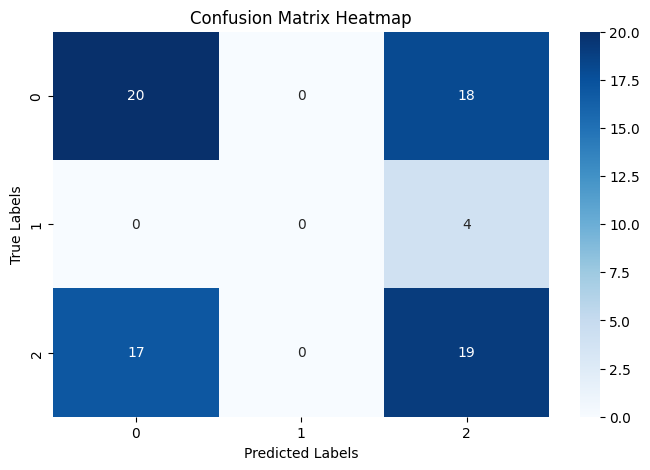

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# رسم نمودار حرارتی برای ماتریس سردرگمی
plt.figure(figsize=(8, 5))
sns.heatmap(a, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## **Keras Classifier Model**

In [15]:
pip install pytorch-forecasting

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [16]:
pip install scikeras

In [17]:
import yfinance as yf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
from sklearn.metrics import accuracy_score
# Scale features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)


In [18]:

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features_scaled, label, test_size=0.3, random_state=42)
import time
start_time = time.time()

# Step 4: Build the Keras model
def build_model():
    model = Sequential()
    model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))  # First hidden layer
    model.add(Dense(32, activation='relu'))  # Second hidden layer
    model.add(Dense(3, activation='softmax'))  # Output layer with sigmoid for binary classification
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Step 5: Wrap the Keras model with KerasClassifier
model = KerasClassifier(model=build_model, epochs=20, batch_size=32, verbose=1)

# Step 6: Train the model
model.fit(X_train, y_train)

# Step 7: Evaluate the model
y_pred = model.predict(X_test)
end_time = time.time()
prediction_time = end_time - start_time
print("Time taken for prediction:", prediction_time, "seconds")
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5114 - loss: 1.0098
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5116 - loss: 0.9612  
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5372 - loss: 0.9135 
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5007 - loss: 0.8924
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5013 - loss: 0.8809 
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5407 - loss: 0.8683  
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5182 - loss: 0.8743  
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5290 - loss: 0.8677  
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5579 - loss: 0.8359 
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5259 - loss: 0.8824 
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4787 - loss: 0.8655 
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5221 - loss: 0.859

In [19]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, precision_score ,recall_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score =", f1)

# Calculate precision
precision = precision_score(y_test, y_pred, average='weighted')
print("Precision =", precision)
# Calculate F1 score
#f1 = f1_score(y_test, y_hat)
#print( "F1_Score =" , f1)
# Calculate precision
#precision = precision_score(y_test, y_hat)
#print("precision = ",precision )
print(f"Accuracy: {accuracy}")
#print(f"F1 Score: {f1}")
#print(f"Precision: {precision}")
#print(df["label"])

recall=recall_score(y_test, y_pred, average='weighted')
print("recall",recall)



F1 Score = 0.4604683705807301
Precision = 0.4534942182001006
Accuracy: 0.48717948717948717
recall 0.48717948717948717


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
from sklearn.metrics import confusion_matrix, classification_report
y_pred = model.predict(X_test)

# محاسبه دقت
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# ماتریس گیج و گزارش طبقه‌بندی
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Accuracy: 0.48717948717948717
Confusion Matrix:
[[26  0 12]
 [ 1  0  3]
 [24  0 12]]

Classification Report:
              precision    recall  f1-score   support

          -1       0.51      0.68      0.58        38
           0       0.00      0.00      0.00         4
           1       0.44      0.33      0.38        36

    accuracy                           0.49        78
   macro avg       0.32      0.34      0.32        78
weighted avg       0.45      0.49      0.46        78



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


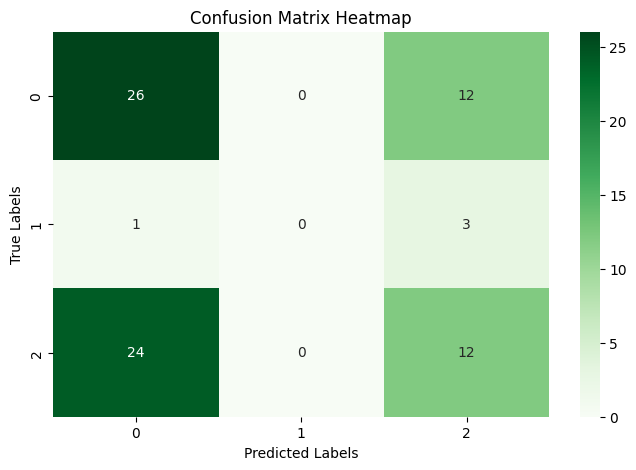

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# رسم نمودار حرارتی برای ماتریس سردرگمی
plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens')

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## **ELM Model**

In [22]:
pip install scikit-elm

In [23]:
pip install dask[distributed]


In [ ]:

import yfinance as yf
import pandas as pd

def download_daily_data_with_1h_intervals(ticker, start_date, end_date):
    data = yf.download(ticker, start=start_date, end=end_date, interval='1h' , period="1d")
    return data

forex_ticker = 'EURUSD=X'  # Replace with the desired Forex pair, e.g., US Dollar to Euro
start_date = '2023-04-01'
end_date = '2024-04-01'

df = download_daily_data_with_1h_intervals(forex_ticker, start_date, end_date)

print(df.head())
df.shape[0]
df.isnull().sum().sum()

[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['EURUSD=X']: YFPricesMissingError('possibly delisted; no price data found  (1h 2023-04-01 -> 2024-04-01) (Yahoo error = "1h data not available for startTime=1680303600 and endTime=1711926000. The requested range must be within the last 730 days.")')


Empty DataFrame
Columns: [(Adj Close, EURUSD=X), (Close, EURUSD=X), (High, EURUSD=X), (Low, EURUSD=X), (Open, EURUSD=X), (Volume, EURUSD=X)]
Index: []


np.int64(0)

In [ ]:
df.columns = [col[0] for col in df.columns]

# Calculate returns
df['Return'] = (df['Close'] - df['Close'].shift(1)) / df['Close'].shift(1)
df = df.dropna()

print(df)

Empty DataFrame
Columns: [Adj Close, Close, High, Low, Open, Volume, Return]
Index: []


In [ ]:
df["label"] = 0
for i in range(1, len(df)):
    if df.loc[df.index[i], "Return"] >= 0.0005:
        df.loc[df.index[i], "label"] = 1
    elif (0 < df.loc[df.index[i], "Return"]) and (df.loc[df.index[i], "Return"] < 0.0005):
        df.loc[df.index[i], "label"] = 0
    elif df.loc[df.index[i], "Return"] < 0:
        df.loc[df.index[i], "label"] = -1


In [ ]:
print(df.shape)


(0, 8)


In [24]:
from sklearn.model_selection import train_test_split
import numpy as np
features = df[['Close' ,"Open" , "Low" ,"High" ]]
label=df["label"]
X_train, X_test, y_train, y_test = train_test_split(features,label, test_size=0.3, random_state=42)
import time
start_time = time.time()


In [25]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# اینجا ی کلاس برای ELM تعریف کردیم
class ELM:
    def __init__(self, input_size, hidden_size, output_size):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.W = np.random.randn(input_size, hidden_size)  # Random weights
        self.beta = None

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def fit(self, X, y):
        H = self.sigmoid(np.dot(X, self.W))
        H_pinv = np.linalg.pinv(H)
        self.beta = np.dot(H_pinv, y)

    def predict(self, X):
        H = self.sigmoid(np.dot(X, self.W))
        return np.dot(H, self.beta)

num_classes = 3  # For classes -1, 0, and 1
y_train_oh = np.zeros((y_train.size, num_classes))

# Map labels -1, 0, 1 to indices 0, 1, 2 for one-hot encoding this is problem for some deeplearning model that need positive label
y_train_mapped = y_train + 1  # This will map -1 to 0, 0 to 1, and 1 to 2
y_train_oh[np.arange(y_train.size), y_train_mapped] = 1
# Convert labels to one-hot encoding


# Define and train the model
elm = ELM(input_size=X_train_scaled.shape[1], hidden_size=10, output_size=3)
elm.fit(X_train_scaled, y_train_oh)

# Predict and evaluate
y_pred = elm.predict(X_test_scaled)
y_pred_class = np.argmax(y_pred, axis=1) - 1  # Convert back to labels -1, 0, 1
accuracy = accuracy_score(y_test, y_pred_class)
print(f"Accuracy: {accuracy}")


Accuracy: 0.4230769230769231


In [26]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, precision_score ,recall_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class, average='weighted')
print("F1 Score =", f1)

# Calculate precision
precision = precision_score(y_test, y_pred_class, average='weighted')
print("Precision =", precision)
# Calculate F1 score
#f1 = f1_score(y_test, y_hat)
#print( "F1_Score =" , f1)
# Calculate precision
#precision = precision_score(y_test, y_hat)
#print("precision = ",precision )
print(f"Accuracy: {accuracy}")
#print(f"F1 Score: {f1}")
#print(f"Precision: {precision}")
#print(df["label"])

recall=recall_score(y_test,y_pred_class, average='weighted')
print("recall",recall)



F1 Score = 0.406051192003782
Precision = 0.396335990707988
Accuracy: 0.4230769230769231
recall 0.4230769230769231


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
from sklearn.metrics import confusion_matrix, classification_report

# تبدیل پیش‌بینی‌های پیوسته به برچسب‌های گسسته
y_pred_class = np.argmax(y_pred, axis=1) - 1  # برچسب‌ها به -1, 0, 1 تبدیل شوند

# محاسبه دقت و ماتریس گیج
accuracy = accuracy_score(y_test, y_pred_class)
conf_matrix = confusion_matrix(y_test, y_pred_class)
class_report = classification_report(y_test, y_pred_class)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


Accuracy: 0.4230769230769231
Confusion Matrix:
[[21  0 17]
 [ 2  0  2]
 [24  0 12]]

Classification Report:
              precision    recall  f1-score   support

          -1       0.45      0.55      0.49        38
           0       0.00      0.00      0.00         4
           1       0.39      0.33      0.36        36

    accuracy                           0.42        78
   macro avg       0.28      0.30      0.28        78
weighted avg       0.40      0.42      0.41        78



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


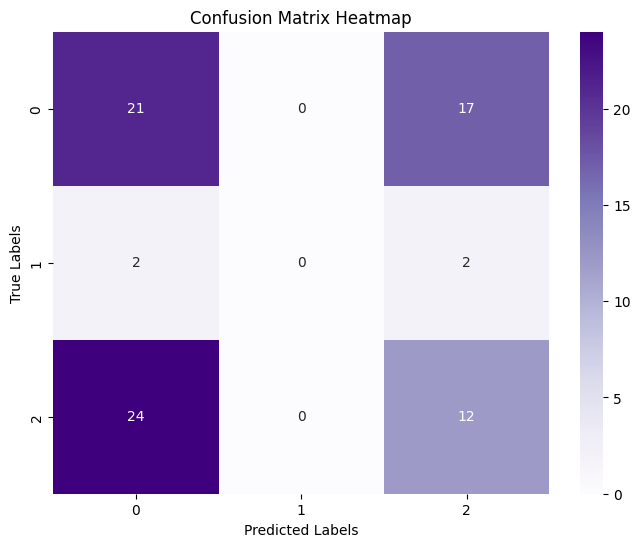

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# رسم نمودار حرارتی برای ماتریس سردرگمی
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples')

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [29]:
pip install pytorch_forecasting

## TFT Model

In [30]:
import numpy as np
import pandas as pd
from pytorch_forecasting.data import TimeSeriesDataSet
from pytorch_forecasting.metrics import CrossEntropy
from pytorch_forecasting.models.temporal_fusion_transformer import TemporalFusionTransformer
from pytorch_lightning import Trainer, LightningModule
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import torch

# --- 1. بارگذاری و آماده‌سازی داده‌ها ---
file_path = "/content/forex_data1.xlsx"  # مسیر فایل داده
df = pd.read_excel(file_path)

# پردازش داده‌ها
df['time_idx'] = np.arange(len(df))  # افزودن اندیس زمانی
df["group_id"] = "EURUSD"  # یک مقدار ثابت برای گروه‌بندی
df['Return'] = (df['Close'] - df['Close'].shift(1)) / df['Close'].shift(1)


In [31]:

# تعریف ستون label بر اساس شرط‌ها
df["label"] = 0
df.loc[df["Return"] >= 0.0005, "label"] = 1
df.loc[(df["Return"] > 0) & (df["Return"] < 0.0005), "label"] = 0
df.loc[df["Return"] < 0, "label"] = -1

# انکود کردن برچسب‌ها به مقادیر صحیح
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["label"])

# ساخت ویژگی‌های جدید
for i in range(1, 6):
    for col in ["Open", "Low", "Close", "High"]:
        df[f"Shifted_{col}_{i}"] = df[col].shift(i)

df.dropna(inplace=True)

In [32]:
# انتخاب ویژگی‌ها
features = [
    'Close', 'Open', 'Low', 'High',
    'Shifted_Open_1', 'Shifted_Low_1', 'Shifted_Close_1', 'Shifted_High_1',
    'Shifted_Open_2', 'Shifted_Low_2', 'Shifted_Close_2', 'Shifted_High_2',
    'Shifted_Open_3', 'Shifted_Low_3', 'Shifted_Close_3', 'Shifted_High_3',
    'Shifted_Open_4', 'Shifted_Low_4', 'Shifted_Close_4', 'Shifted_High_4',
    'Shifted_Open_5', 'Shifted_Low_5', 'Shifted_Close_5', 'Shifted_High_5'
]

In [33]:
# --- 2. تعریف TimeSeriesDataSet ---
max_encoder_length = 48  # طول دنباله برای ورودی
max_prediction_length = 24  # طول دنباله برای پیش‌بینی
import time
start_time = time.time()
dataset = TimeSeriesDataSet(
    df,
    time_idx="time_idx",
    target="label",  # هدف
    group_ids=["group_id"],
    time_varying_known_reals=features,
    time_varying_unknown_reals=["label"],  # هدف به‌عنوان ویژگی ناشناخته
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
)

# DataLoader برای آموزش
dataloader = dataset.to_dataloader(train=True, batch_size=64, num_workers=0)

# --- 3. تعریف مدل TFT ---
tft = TemporalFusionTransformer.from_dataset(
    dataset,
    hidden_size=5,
    lstm_layers=2,
    dropout=0.1,
    #learning_rate=1e-3,
    learning_rate=0.1,
    loss=CrossEntropy(),  # استفاده از CrossEntropyLoss برای طبقه‌بندی
)


/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [34]:

# --- 4. تعریف LightningModule ---
class TFTLightningModule(LightningModule):
    def __init__(self, tft_model):
        super().__init__()
        self.tft_model = tft_model

    def forward(self, x):
        return self.tft_model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch

        # انتقال داده‌ها به دستگاه
        x = {k: v.to(self.device) for k, v in x.items()}
        if isinstance(y, tuple):
            y = y[0]
        y = y.to(self.device)

        # پیش‌بینی و محاسبه Loss
        y_hat = self.tft_model(x)
        loss = self.tft_model.loss(y_hat["prediction"], y)
        self.log("train_loss", loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)


# --- 5. آموزش ---
# اینجا مدل TFTLightningModule را از مدل TFT ایجاد می‌کنیم
lightning_model = TFTLightningModule(tft)

trainer = Trainer(
    max_epochs=5,
    devices=1,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    logger=False,
    enable_checkpointing=False,
)

# آموزش مدل
trainer.fit(lightning_model, train_dataloaders=dataloader)
end_time = time.time()
prediction_time = end_time - start_time

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type                      | Params | Mode 
----------------------------------------------------------------
0 | tft_model | TemporalFusionTransformer | 13.2 K | train
----------------------------------------------------------------
13.2 K    Trainable params
0         Non-trainable params
13.2 K    Total params
0.053     Total estimated model params size (MB)
859       Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


In [35]:

# --- 6. پیش‌بینی ---
predictions = []
actual_values = []

for batch in dataloader:
    x, y = batch

    # انتقال داده‌ها به دستگاه مناسب
    x = {k: v.to(lightning_model.device) for k, v in x.items()}
    if isinstance(y, tuple):
        y = y[0]
    y = y.to(lightning_model.device)

    with torch.no_grad():
        y_hat = tft(x)["prediction"].argmax(dim=1)
    predictions.append(y_hat.cpu().numpy())
    actual_values.append(y.cpu().numpy())

# تبدیل به numpy array
predicted_values = np.concatenate(predictions).flatten()
actual_values = np.concatenate(actual_values).flatten()

# محاسبه دقت

# --- همگام‌سازی داده‌ها ---
min_length = min(len(predicted_values), len(actual_values))
predicted_values = predicted_values[:min_length]
actual_values = actual_values[:min_length]

# تبدیل پیش‌بینی‌ها و مقادیر واقعی به کلاس‌ها
predicted_classes = (predicted_values > 0).astype(int)  # پیش‌بینی به کلاس‌ها
actual_classes = (actual_values > 0).astype(int)  # مقادیر واقعی به کلاس‌ها

# --- محاسبه دقت ---
accuracy = accuracy_score(actual_classes, predicted_classes)
print(f"Accuracy: {accuracy:.4f}")

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Calculate Accuracy
accuracy = accuracy_score(actual_classes, predicted_classes)

# Calculate Precision
precision = precision_score(actual_classes, predicted_classes, average='weighted')  # 'weighted' handles multi-class

# Calculate Recall
recall = recall_score(actual_classes, predicted_classes, average='weighted')  # 'weighted' handles multi-class

# Calculate F1 Score
f1 = f1_score(actual_classes,predicted_classes, average='weighted')  # 'weighted' handles multi-class

# Displaying the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Time taken for prediction:", prediction_time, "seconds")

Accuracy: 0.5419
Accuracy: 0.5419
Precision: 0.5126
Recall: 0.5419
F1 Score: 0.4383
Time taken for prediction: 288.97669196128845 seconds


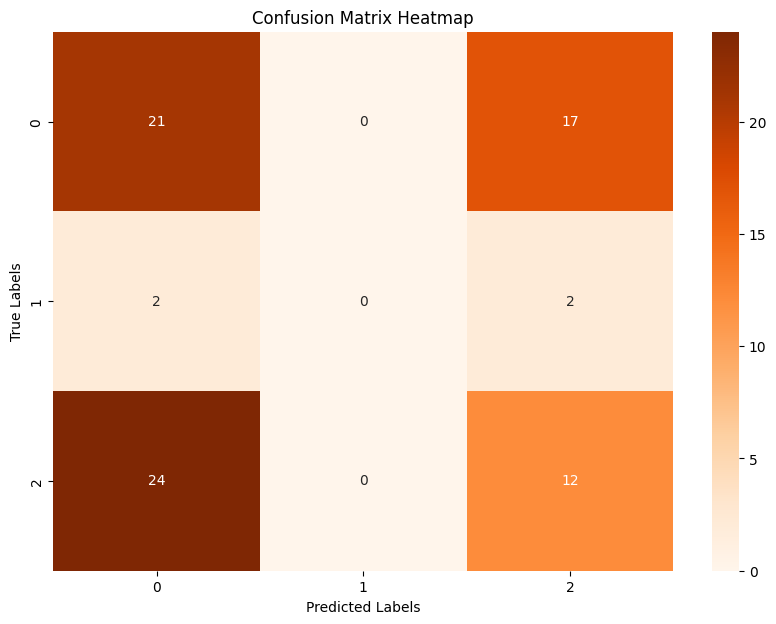

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges')

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## **Phlinet Model**

In [45]:
import yfinance as yf
import pandas as pd

def download_daily_data(ticker, start_date, end_date):
    data = yf.download(ticker, start=start_date, end=end_date, interval='1d', auto_adjust=False)
    return data

forex_ticker = 'EURUSD=X'  # Euro to US Dollar
start_date = '2023-04-01'
end_date = '2024-04-01'

df = download_daily_data(forex_ticker, start_date, end_date)

print(df.head())
print(f"Rows: {df.shape[0]}")

# پیش‌پردازش داده‌ها
df['Return'] = (df['Close'] - df['Close'].shift(1)) / df['Close'].shift(1)
df.dropna(inplace=True)
df['label'] = 0
df.loc[df['Return'] >= 0.0005, 'label'] = 1
df.loc[df['Return'] < 0, 'label'] = 2


[*********************100%***********************]  1 of 1 completed

Price      Adj Close     Close      High       Low      Open   Volume
Ticker      EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X EURUSD=X
Date                                                                 
2023-04-03  0.925712  0.925712  0.926879  0.916170  0.925712        0
2023-04-04  0.916758  0.916758  0.918847  0.911461  0.916758        0
2023-04-05  0.912642  0.912642  0.917036  0.911660  0.912642        0
2023-04-06  0.917086  0.917086  0.918712  0.915097  0.917196        0
2023-04-07  0.915793  0.915793  0.919033  0.915441  0.915793        0
Rows: 260


In [46]:
import yfinance as yf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score
features = df[['Open', 'High', 'Low', 'Close']].values
target = df['label'].values

scaler = StandardScaler()
features = scaler.fit_transform(features)

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42, shuffle=True)

X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)  # برای LSTM به حالت سری زمانی
X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [47]:

# تعریف مدل جدید با LSTM، FeedForward و Smooth Layer
class philnet(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(philnet, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc1 = nn.Linear(hidden_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.smooth_layer = nn.Linear(64, num_classes)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x = lstm_out[:, -1, :]  # آخرین خروجی LSTM
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.smooth_layer(x)
        return x

input_dim = X_train.shape[2]
hidden_dim = 128
num_classes = len(np.unique(y_train))

model = philnet(input_dim, hidden_dim, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [48]:
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# محدوده‌های جستجو برای هایپرپارامترها
param_grid = {
    'hidden_dim': [32, 64, 128],
    'lr': [0.001, 0.01],
    'batch_size': [16, 32, 64],
    'num_epochs': [20, 30]
}

# تولید ترکیب‌های مختلف از پارامترها
param_combinations = list(product(*param_grid.values()))

best_models = {
    'accuracy': {'score': 0, 'params': {}, 'model': None},
    'f1_score': {'score': 0, 'params': {}, 'model': None},
    'precision': {'score': 0, 'params': {}, 'model': None},
    'recall': {'score': 0, 'params': {}, 'model': None},
}

for params in param_combinations:
    hidden_dim, lr, batch_size, num_epochs = params
    print(f"Training with params: hidden_dim={hidden_dim}, lr={lr}, batch_size={batch_size}, num_epochs={num_epochs}")

    model = philnet(input_dim, hidden_dim, num_classes)  # فرض بر این است که مدل PhilNet تعریف شده است
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # آموزش مدل
    for epoch in range(num_epochs):
        model.train()
        permutation = torch.randperm(X_train.size()[0])
        for i in range(0, X_train.size()[0], batch_size):
            indices = permutation[i:i + batch_size]
            batch_x, batch_y = X_train[indices], y_train[indices]
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

    # ارزیابی مدل
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test)
        _, predicted = torch.max(test_outputs, 1)
        accuracy = accuracy_score(y_test, predicted)
        f1 = f1_score(y_test, predicted, average='weighted')
        precision = precision_score(y_test, predicted, average='weighted')
        recall = recall_score(y_test, predicted, average='weighted')

    # بررسی و به‌روزرسانی بهترین مدل برای هر معیار
    metrics = {
        'accuracy': accuracy,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
    }

    for metric, score in metrics.items():
        if score > best_models[metric]['score']:
            best_models[metric]['score'] = score
            best_models[metric]['params'] = {
                'hidden_dim': hidden_dim,
                'lr': lr,
                'batch_size': batch_size,
                'num_epochs': num_epochs
            }
            best_models[metric]['model'] = model

    print(f"Metrics for current params: Accuracy={accuracy}, F1 Score={f1}, Precision={precision}, Recall={recall}")

# نمایش بهترین پارامترها برای هر معیار
for metric, info in best_models.items():
    print(f"\nBest Parameters for {metric}:")
    print(info['params'])
    print(f"Best {metric.capitalize()}: {info['score']}")


Training with params: hidden_dim=32, lr=0.001, batch_size=16, num_epochs=20


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Metrics for current params: Accuracy=0.44871794871794873, F1 Score=0.398046398046398, Precision=0.40683760683760684, Recall=0.44871794871794873
Training with params: hidden_dim=32, lr=0.001, batch_size=16, num_epochs=30


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Metrics for current params: Accuracy=0.5128205128205128, F1 Score=0.4976882504269046, Precision=0.4847602010392707, Recall=0.5128205128205128
Training with params: hidden_dim=32, lr=0.001, batch_size=32, num_epochs=20


...

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Metrics for current params: Accuracy=0.48717948717948717, F1 Score=0.31918656056587086, Precision=0.23734385272846809, Recall=0.48717948717948717
Training with params: hidden_dim=128, lr=0.01, batch_size=64, num_epochs=20


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Metrics for current params: Accuracy=0.5512820512820513, F1 Score=0.5367912290989215, Precision=0.52304318488529, Recall=0.5512820512820513
Training with params: hidden_dim=128, lr=0.01, batch_size=64, num_epochs=30
Metrics for current params: Accuracy=0.44871794871794873, F1 Score=0.3673570019723866, Precision=0.3826728826728827, Recall=0.44871794871794873

Best Parameters for accuracy:
{'hidden_dim': 32, 'lr': 0.01, 'batch_size': 64, 'num_epochs': 20}
Best Accuracy: 0.5512820512820513

Best Parameters for f1_score:
{'hidden_dim': 128, 'lr': 0.01, 'batch_size': 64, 'num_epochs': 20}
Best F1_score: 0.5367912290989215

Best Parameters for precision:
{'hidden_dim': 128, 'lr': 0.01, 'batch_size': 16, 'num_epochs': 30}
Best Precision: 0.5469182389937106

Best Parameters for recall:
{'hidden_dim': 32, 'lr': 0.01, 'batch_size': 64, 'num_epochs': 20}
Best Recall: 0.5512820512820513


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [49]:
cm = confusion_matrix(y_test, predicted)
report = classification_report(y_test, predicted, target_names=['Class 0', 'Class 1', 'Class 2'])

print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(report)




Confusion Matrix:
[[ 0  1  3]
 [ 0  4 32]
 [ 0  7 31]]

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00         4
     Class 1       0.33      0.11      0.17        36
     Class 2       0.47      0.82      0.60        38

    accuracy                           0.45        78
   macro avg       0.27      0.31      0.25        78
weighted avg       0.38      0.45      0.37        78



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


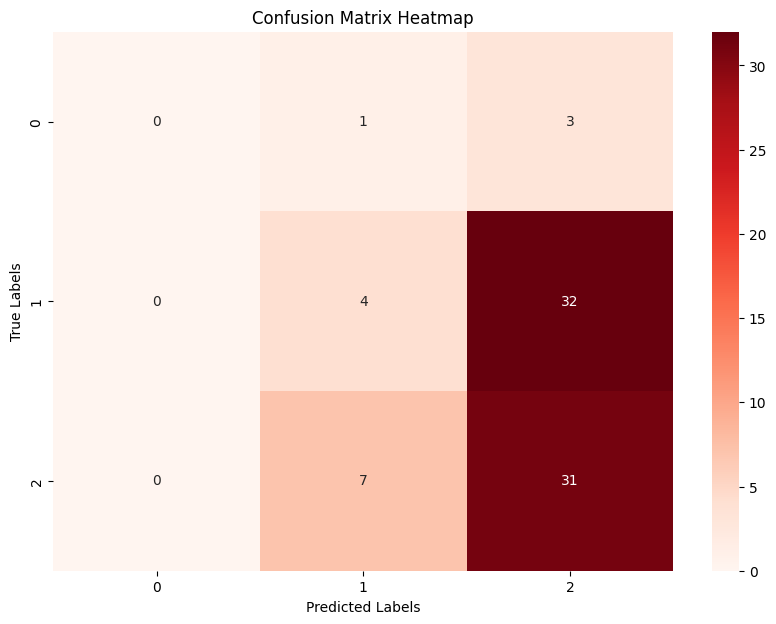

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# رسم نمودار حرارتی برای ماتریس سردرگمی
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()